## SETUP

In [ ]:
from pathlib import Path

import pandas as pd
import tensorflow as tf
import yaml
from tensorflow.keras.losses import BinaryCrossentropy
from tensorflow.keras.metrics import AUC, BinaryAccuracy, Precision, Recall
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau,
)

from breast_cancer.data import optimize_dataset, prepare_dataset
from breast_cancer.models import build_from_config
from breast_cancer.utils import get_save_path
from breast_cancer.train import train_model
from breast_cancer.utils.plots import plot_history

In [21]:
# Check installed tensorflow version
print(f"Tensorflow version: {tf.__version__}")

# Check GPU availability
print(f"GPU List: {tf.config.list_physical_devices('GPU')}")

Tensorflow version: 2.10.1
GPU List: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [22]:
# Import general configurations
with open("../configs/default.yml") as f:
    default_cfg = yaml.load(f, Loader=yaml.FullLoader)

# Import training configurations
with open("../configs/training.yml") as f:
    training_cfg = yaml.load(f, Loader=yaml.FullLoader)

# Import model configurations
with open("../configs/model_cnn_extended.yml") as f:
    model_cfg = yaml.load(f, Loader=yaml.FullLoader)

In [23]:
dir_data_split = Path(default_cfg["dirs"]["data_split"])
dir_data_split.mkdir(parents=True, exist_ok=True)

dir_model_logs = Path(default_cfg["dirs"]["model_logs"])
dir_model_logs.mkdir(parents=True, exist_ok=True)

dir_model_initial = Path(default_cfg["dirs"]["model_initial"])
dir_model_initial.mkdir(parents=True, exist_ok=True)

dir_model_final = Path(default_cfg["dirs"]["model_final"])
dir_model_final.mkdir(parents=True, exist_ok=True)

In [24]:
def get_dataset(image_paths, image_labels, image_resize, dataset_cfg):
    if isinstance(image_resize, int):
        image_resize = (image_resize, image_resize)
    dataset = prepare_dataset(image_paths, image_labels, image_resize)
    dataset = optimize_dataset(dataset, **dataset_cfg)
    return dataset

In [25]:
# Set random seeds
tf.random.set_seed(default_cfg["random_seed"])

In [26]:
EPOCHS = 80

## MODEL STARTING POINT

In [27]:
# Build model from spec
model = build_from_config(model_cfg["model_args"])
model.summary()

# Save initial weights for multiple training configurations
save_path = get_save_path(default_cfg["dirs"]["model_initial"], f"{model.name}", "")
model.save_weights(save_path)
print(f"Model initial weights are saved at {save_path}")

Model: "cnn_extended"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_2 (InputLayer)        [(None, 256, 256, 1)]     0         
                                                                 
 conv2d_8 (Conv2D)           (None, 252, 252, 4)       104       
                                                                 
 conv2d_9 (Conv2D)           (None, 250, 250, 8)       296       
                                                                 
 max_pooling2d_6 (MaxPooling  (None, 125, 125, 8)      0         
 2D)                                                             
                                                                 
 batch_normalization_8 (Batc  (None, 125, 125, 8)      32        
 hNormalization)                                                 
                                                                 
 spatial_dropout2d_6 (Spatia  (None, 125, 125, 8)     

Model initial weights are saved at ../models/initial/cnn_extended/cnn_extended


## MODEL EXPLORATION

#### Split by image ID

In [9]:
df_train_image_random = pd.read_csv(dir_data_split / "train_image_random_aug.csv") # get the augmented version
df_val_image_random = pd.read_csv(dir_data_split / "val_image_random.csv")

df_train_image_random.head(3)

,Unnamed: 0,raw,processed,imageID,patientID,label,augmented,augmentID
0,0,../data/images/raw/benign/Calc-Training_P_0000...,../data/images/processed/Calc-Training_P_00007...,Calc-Training_P_00007_LEFT_CC_1,P_00007,benign,../data/images/augmented/Calc-Training_P_00007...,Calc-Training_P_00007_LEFT_CC_1-augmented-9
1,1,../data/images/raw/benign/Calc-Training_P_0000...,../data/images/processed/Calc-Training_P_00007...,Calc-Training_P_00007_LEFT_CC_1,P_00007,benign,../data/images/augmented/Calc-Training_P_00007...,Calc-Training_P_00007_LEFT_CC_1-augmented-8
2,2,../data/images/raw/benign/Calc-Training_P_0000...,../data/images/processed/Calc-Training_P_00007...,Calc-Training_P_00007_LEFT_CC_1,P_00007,benign,../data/images/augmented/Calc-Training_P_00007...,Calc-Training_P_00007_LEFT_CC_1-augmented-7


In [10]:
ds_train_image_random = get_dataset(
    df_train_image_random["augmented"].values,
    df_train_image_random["label"].values,
    image_resize=default_cfg["image_resize"],
    dataset_cfg=training_cfg["dataset"]["train"],
)

ds_val_image_random = get_dataset(
    df_val_image_random["processed"].values,
    df_val_image_random["label"].values,
    image_resize=default_cfg["image_resize"],
    dataset_cfg=training_cfg["dataset"]["test"],
)

In [ ]:
# Load the model initial weights
model.load_weights(save_path)

# Compile model with optimizer, loss, and metrics
optimizer = Adam(learning_rate=training_cfg["initial_training"]["lr"])
loss = BinaryCrossentropy()
metrics = [AUC(), BinaryAccuracy(), Precision(), Recall()]

model.compile(optimizer=optimizer, loss=loss, metrics=metrics)

# Setup callbacks
early_stop = EarlyStopping(monitor="val_loss", **training_cfg["initial_training"]["early_stopping"])
lr_reducer = ReduceLROnPlateau(monitor="val_loss", **training_cfg["initial_training"]["reduce_on_plateau"])

In [12]:
# Train model
history_image = model.fit(
    ds_train_image_random,
    validation_data=ds_val_image_random,
    callbacks=[early_stop, lr_reducer],
    epochs=EPOCHS,
)

Epoch 1/80


2025-09-21 10:58:16.526225: I tensorflow/stream_executor/cuda/cuda_dnn.cc:384] Loaded cuDNN version 8905
2025-09-21 10:58:16.552733: I tensorflow/core/platform/default/subprocess.cc:304] Start cannot spawn child process: No such file or directory
2025-09-21 10:58:16.554033: I tensorflow/core/platform/default/subprocess.cc:304] Start cannot spawn child process: No such file or directory
2025-09-21 10:58:16.554046: W tensorflow/stream_executor/gpu/asm_compiler.cc:80] Couldn't get ptxas version string: INTERNAL: Couldn't invoke ptxas --version
2025-09-21 10:58:16.554410: I tensorflow/core/platform/default/subprocess.cc:304] Start cannot spawn child process: No such file or directory
2025-09-21 10:58:16.554449: W tensorflow/stream_executor/gpu/redzone_allocator.cc:314] INTERNAL: Failed to launch ptxas
Relying on driver to perform ptx compilation. 
Modify $PATH to customize ptxas location.
This message will be only logged once.
2025-09-21 10:58:16.738425: I tensorflow/stream_executor/cuda/c

323/323 [==============================] - 17s 45ms/step - loss: 9.5713 - auc: 0.5014 - binary_accuracy: 0.5068 - precision: 0.4122 - recall: 0.4595 - val_loss: 8.3639 - val_auc: 0.6009 - val_binary_accuracy: 0.5026 - val_precision: 0.4404 - val_recall: 0.7669 - lr: 1.0000e-04
Epoch 2/80
323/323 [==============================] - 14s 41ms/step - loss: 7.6028 - auc: 0.4894 - binary_accuracy: 0.5030 - precision: 0.4027 - recall: 0.4236 - val_loss: 6.6066 - val_auc: 0.5810 - val_binary_accuracy: 0.5550 - val_precision: 0.4693 - val_recall: 0.6144 - lr: 1.0000e-04
Epoch 3/80
323/323 [==============================] - 14s 40ms/step - loss: 5.9814 - auc: 0.5065 - binary_accuracy: 0.5231 - precision: 0.4202 - recall: 0.4112 - val_loss: 5.1789 - val_auc: 0.5452 - val_binary_accuracy: 0.5672 - val_precision: 0.4318 - val_recall: 0.1610 - lr: 1.0000e-04
Epoch 4/80
323/323 [==============================] - 14s 40ms/step - loss: 4.7017 - auc: 0.5005 - binary_accuracy: 0.5185 - precision: 0.4095 -

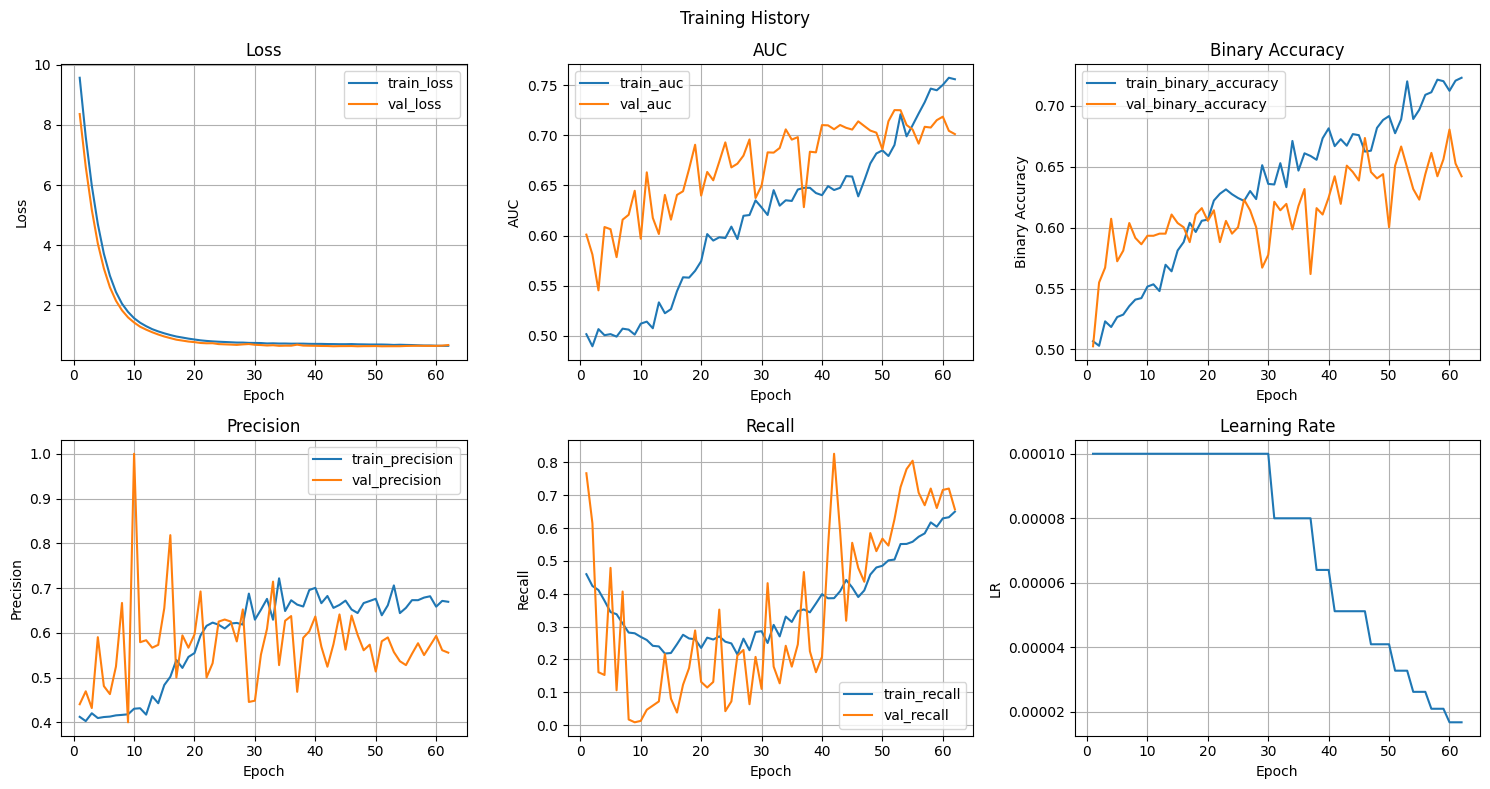

In [13]:
plot_history(history_image)

In [14]:
logger_path = str(dir_model_logs/model.name/f"initial_{model.name}_image_random.csv")
Path(logger_path).parent.mkdir(exist_ok=True)

pd.DataFrame(history_image.history).to_csv(logger_path)

f"Saved at {logger_path}"

'Saved at ../models/logs/cnn_extended/initial_cnn_extended_image_random.csv'

#### Split by patient ID

In [15]:
df_train_patient_random = pd.read_csv(dir_data_split / "train_patient_random_aug.csv") # get the augmented version
df_val_patient_random = pd.read_csv(dir_data_split / "val_patient_random.csv")

df_train_patient_random.head(3)

,Unnamed: 0,raw,processed,imageID,patientID,label,augmented,augmentID
0,0,../data/images/raw/benign/Calc-Test_P_00038_LE...,../data/images/processed/Calc-Test_P_00038_LEF...,Calc-Test_P_00038_LEFT_CC_1,P_00038,benign,../data/images/augmented/Calc-Test_P_00038_LEF...,Calc-Test_P_00038_LEFT_CC_1-augmented-9
1,1,../data/images/raw/benign/Calc-Test_P_00038_LE...,../data/images/processed/Calc-Test_P_00038_LEF...,Calc-Test_P_00038_LEFT_CC_1,P_00038,benign,../data/images/augmented/Calc-Test_P_00038_LEF...,Calc-Test_P_00038_LEFT_CC_1-augmented-8
2,2,../data/images/raw/benign/Calc-Test_P_00038_LE...,../data/images/processed/Calc-Test_P_00038_LEF...,Calc-Test_P_00038_LEFT_CC_1,P_00038,benign,../data/images/augmented/Calc-Test_P_00038_LEF...,Calc-Test_P_00038_LEFT_CC_1-augmented-7


In [16]:
ds_train_patient_random = get_dataset(
    df_train_patient_random["augmented"].values,
    df_train_patient_random["label"].values,
    image_resize=default_cfg["image_resize"],
    dataset_cfg=training_cfg["dataset"]["train"],
)

ds_val_patient_random = get_dataset(
    df_val_patient_random["processed"].values,
    df_val_patient_random["label"].values,
    image_resize=default_cfg["image_resize"],
    dataset_cfg=training_cfg["dataset"]["test"],
)

In [ ]:
# Load the model initial weights
model.load_weights(save_path)

# Compile model with optimizer, loss, and metrics
optimizer = Adam(learning_rate=training_cfg["initial_training"]["lr"])
loss = BinaryCrossentropy()
metrics = [AUC(), BinaryAccuracy(), Precision(), Recall()]

model.compile(optimizer=optimizer, loss=loss, metrics=metrics)

# Setup callbacks
early_stop = EarlyStopping(monitor="val_loss", **training_cfg["initial_training"]["early_stopping"])
lr_reducer = ReduceLROnPlateau(monitor="val_loss", **training_cfg["initial_training"]["reduce_on_plateau"])

In [22]:
# Train model
history_patient = model.fit(
    ds_train_patient_random,
    validation_data=ds_val_patient_random,
    callbacks=[early_stop, lr_reducer],
    epochs=EPOCHS,
)

Epoch 1/80
316/316 [==============================] - 18s 46ms/step - loss: 9.5726 - auc_1: 0.4977 - binary_accuracy: 0.5028 - precision_1: 0.3994 - recall_1: 0.4564 - val_loss: 8.3801 - val_auc_1: 0.4844 - val_binary_accuracy: 0.3993 - val_precision_1: 0.3970 - val_recall_1: 1.0000 - lr: 1.0000e-04
Epoch 2/80
316/316 [==============================] - 12s 36ms/step - loss: 7.6096 - auc_1: 0.5029 - binary_accuracy: 0.5143 - precision_1: 0.4037 - recall_1: 0.4222 - val_loss: 6.6522 - val_auc_1: 0.5608 - val_binary_accuracy: 0.4776 - val_precision_1: 0.4220 - val_recall_1: 0.8679 - lr: 1.0000e-04
Epoch 3/80
316/316 [==============================] - 13s 35ms/step - loss: 6.0250 - auc_1: 0.4950 - binary_accuracy: 0.5130 - precision_1: 0.3950 - recall_1: 0.3850 - val_loss: 5.2211 - val_auc_1: 0.6163 - val_binary_accuracy: 0.6343 - val_precision_1: 0.6250 - val_recall_1: 0.1887 - lr: 1.0000e-04
Epoch 4/80
316/316 [==============================] - 14s 41ms/step - loss: 4.7436 - auc_1: 0.496

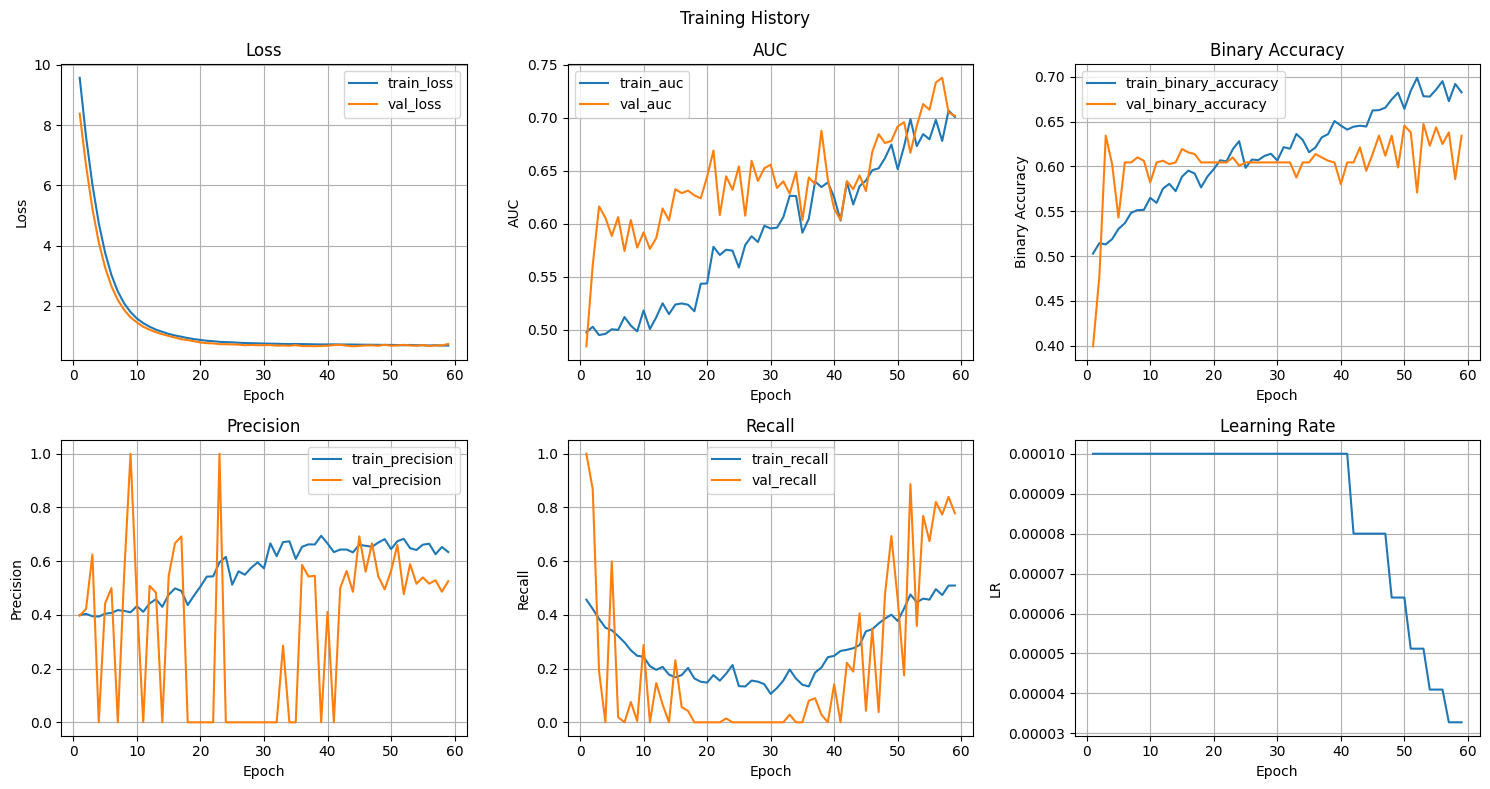

In [ ]:
import re
history = {}

for key in history_patient.history.keys():
    new_key = re.sub(r"_\d$", "", key)
    history[new_key] = history_patient.history[key]

plot_history(history)

In [19]:
logger_path = str(dir_model_logs/model.name/f"initial_{model.name}_patient_random.csv")

pd.DataFrame(history_patient.history).to_csv(logger_path)

f"Saved at {logger_path}"

'Saved at ../models/logs/cnn_extended/initial_cnn_extended_patient_random.csv'

## FINAL EVALUATION

#### Split by Image ID

In [35]:
df_train_image_random = pd.read_csv(dir_data_split / "train_image_random_aug.csv") # get the augmented version
df_val_image_random = pd.read_csv(dir_data_split / "val_image_random_aug.csv") # get the augmented version

# Combine train and val data for full training
df_full_train_image_random = pd.concat([df_train_image_random, df_val_image_random], ignore_index=True)

ds_full_train_image_random = get_dataset(
    df_full_train_image_random["augmented"].values,
    df_full_train_image_random["label"].values,
    image_resize=default_cfg["image_resize"],
    dataset_cfg=training_cfg["dataset"]["train"],
) # .map(lambda x, y: (grayscale_to_rgb(x), y)) # convert to 3-channel images

In [36]:
# Load the model initial weights
model.load_weights(save_path)

# Compile model with optimizer, loss, and metrics
optimizer = Adam(learning_rate=training_cfg["final_training"]["lr"])
loss = BinaryCrossentropy()
metrics = [AUC(), BinaryAccuracy(), Precision(), Recall()]

model.compile(optimizer=optimizer, loss=loss, metrics=metrics)

# Setup callbacks
early_stop = EarlyStopping(monitor="loss", **training_cfg["final_training"]["early_stopping"])
lr_reducer = ReduceLROnPlateau(monitor="loss", **training_cfg["final_training"]["reduce_on_plateau"])

In [37]:
# Train model
history_image_full = model.fit(
    ds_full_train_image_random,
    callbacks=[early_stop, lr_reducer],
    epochs=25, # when model start to overfit during experiments
)

Epoch 1/25
403/403 [==============================] - 17s 35ms/step - loss: 9.3555 - auc_3: 0.5151 - binary_accuracy: 0.5181 - precision_3: 0.4246 - recall_3: 0.4751 - lr: 1.0000e-04
Epoch 2/25
403/403 [==============================] - 8s 20ms/step - loss: 7.0862 - auc_3: 0.5087 - binary_accuracy: 0.5184 - precision_3: 0.4185 - recall_3: 0.4310 - lr: 1.0000e-04
Epoch 3/25
403/403 [==============================] - 8s 21ms/step - loss: 5.3365 - auc_3: 0.5105 - binary_accuracy: 0.5223 - precision_3: 0.4179 - recall_3: 0.4030 - lr: 1.0000e-04
Epoch 4/25
403/403 [==============================] - 8s 21ms/step - loss: 4.0308 - auc_3: 0.5182 - binary_accuracy: 0.5341 - precision_3: 0.4279 - recall_3: 0.3854 - lr: 1.0000e-04
Epoch 5/25
403/403 [==============================] - 8s 21ms/step - loss: 3.0935 - auc_3: 0.5204 - binary_accuracy: 0.5410 - precision_3: 0.4319 - recall_3: 0.3584 - lr: 1.0000e-04
Epoch 6/25
403/403 [==============================] - 8s 21ms/step - loss: 2.4383 - auc_3

In [38]:
# Save final model
model.save(dir_model_final/model.name/f"{model.name}_image_random.h5")

In [39]:
# Setup testing data for evaluation
df_test_image_random = pd.read_csv(dir_data_split / "test_image_random.csv")

ds_test_image_random = prepare_dataset( # use prepare dataset, only converting path to image and get labels
    df_test_image_random["processed"].values,
    df_test_image_random["label"].values,
    image_resize=(default_cfg["image_resize"], default_cfg["image_resize"])
) # .map(lambda x, y: (grayscale_to_rgb(x), y)) # convert to 3-channel images

ds_test_image_random = ds_test_image_random.batch(64)

In [40]:
# Final evaluation
model.evaluate(ds_test_image_random)

11/11 [==============================] - 1s 72ms/step - loss: 0.7560 - auc_3: 0.6429 - binary_accuracy: 0.6051 - precision_3: 0.4968 - recall_3: 0.5543   


[0.7559767365455627,
 0.6429000496864319,
 0.6051136255264282,
 0.4967532455921173,
 0.554347813129425]

In [41]:
#Export final training history
logger_path = str(dir_model_logs/model.name/f"full_{model.name}_image_random.csv")

pd.DataFrame(history_image_full.history).to_csv(logger_path)

f"Saved at {logger_path}"

'Saved at ../models/logs/cnn_extended/full_cnn_extended_image_random.csv'

In [42]:
#Export final training history
logger_path = str(dir_model_logs/model.name/f"full_{model.name}_image_random.csv")

pd.DataFrame(history_image_full.history).to_csv(logger_path)

f"Saved at {logger_path}"

'Saved at ../models/logs/cnn_extended/full_cnn_extended_image_random.csv'

#### Split by Patient ID

In [28]:
df_train_patient_random = pd.read_csv(dir_data_split / "train_patient_random_aug.csv") # get the augmented version
df_val_patient_random = pd.read_csv(dir_data_split / "val_patient_random_aug.csv") # get the augmented version

# Combine train and val data for full training
df_full_train_patient_random = pd.concat([df_train_patient_random, df_val_patient_random], ignore_index=True)

ds_full_train_patient_random = get_dataset(
    df_full_train_patient_random["augmented"].values,
    df_full_train_patient_random["label"].values,
    image_resize=default_cfg["image_resize"],
    dataset_cfg=training_cfg["dataset"]["train"],
) # .map(lambda x, y: (grayscale_to_rgb(x), y)) # convert to 3-channel images

In [29]:
# Load the model initial weights
model.load_weights(save_path)

# Compile model with optimizer, loss, and metrics
optimizer = Adam(learning_rate=training_cfg["final_training"]["lr"])
loss = BinaryCrossentropy()
metrics = [AUC(), BinaryAccuracy(), Precision(), Recall()]

model.compile(optimizer=optimizer, loss=loss, metrics=metrics)

# Setup callbacks
early_stop = EarlyStopping(monitor="loss", **training_cfg["final_training"]["early_stopping"])
lr_reducer = ReduceLROnPlateau(monitor="loss", **training_cfg["final_training"]["reduce_on_plateau"])

In [30]:
# Train model
history_patient_full = model.fit(
    ds_full_train_patient_random,
    callbacks=[early_stop, lr_reducer],
    epochs=35, # when model start to overfit during experiments
)

Epoch 1/35


392/392 [==============================] - 17s 27ms/step - loss: 9.4037 - auc_2: 0.5127 - binary_accuracy: 0.5161 - precision_2: 0.4107 - recall_2: 0.4645 - lr: 1.0000e-04
Epoch 2/35
392/392 [==============================] - 8s 21ms/step - loss: 7.1980 - auc_2: 0.5060 - binary_accuracy: 0.5138 - precision_2: 0.4014 - recall_2: 0.4231 - lr: 1.0000e-04
Epoch 3/35
392/392 [==============================] - 8s 21ms/step - loss: 5.4987 - auc_2: 0.5102 - binary_accuracy: 0.5272 - precision_2: 0.4090 - recall_2: 0.3915 - lr: 1.0000e-04
Epoch 4/35
392/392 [==============================] - 8s 20ms/step - loss: 4.1984 - auc_2: 0.5091 - binary_accuracy: 0.5339 - precision_2: 0.4094 - recall_2: 0.3564 - lr: 1.0000e-04
Epoch 5/35
392/392 [==============================] - 8s 21ms/step - loss: 3.2414 - auc_2: 0.5108 - binary_accuracy: 0.5397 - precision_2: 0.4098 - recall_2: 0.3258 - lr: 1.0000e-04
Epoch 6/35
392/392 [==============================] - 8s 21ms/step - loss: 2.5543 - auc_2: 0.5236 - 

In [31]:
# Save final model
model.save(dir_model_final/model.name/f"{model.name}_patient_random.h5")

In [32]:
#Export final training history
logger_path = str(dir_model_logs/model.name/f"full_{model.name}_patient_random.csv")

pd.DataFrame(history_patient_full.history).to_csv(logger_path)

f"Saved at {logger_path}"

'Saved at ../models/logs/cnn_extended/full_cnn_extended_patient_random.csv'

In [33]:
# Setup testing data for evaluation
df_test_patient_random = pd.read_csv(dir_data_split / "test_patient_random.csv")

ds_test_patient_random = prepare_dataset( # use prepare dataset, only converting path to image and get labels
    df_test_patient_random["processed"].values,
    df_test_patient_random["label"].values,
    image_resize=(default_cfg["image_resize"], default_cfg["image_resize"])
) # .map(lambda x, y: (grayscale_to_rgb(x), y)) # convert to 3-channel images

ds_test_patient_random = ds_test_patient_random.batch(64)

In [34]:
# Final evaluation
model.evaluate(ds_test_patient_random)

13/13 [==============================] - 1s 27ms/step - loss: 0.7246 - auc_2: 0.6866 - binary_accuracy: 0.6043 - precision_2: 0.5253 - recall_2: 0.8012 


[0.7245647311210632,
 0.6866495609283447,
 0.6043257117271423,
 0.5252918004989624,
 0.8011869192123413]